In [2]:
# import libraries
from getpass import getpass
import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
from datetime import datetime,timedelta
from shapely.geometry import Polygon, Point, box, MultiPoint
from shapely.ops import unary_union
import rasterio
from rasterio.control import GroundControlPoint
from rasterio.crs import CRS
from rasterio.features import rasterize
from affine import Affine
import xml.etree.ElementTree as ET
import geopandas as gpd
import zipfile
import tempfile
import re
from eodms_api_client import EodmsAPI
from scipy.interpolate import interp1d
import shutil
from netCDF4 import Dataset
from scipy.interpolate import griddata
from scipy.ndimage import map_coordinates


Retrieve, Search, and Download RCM Scenes based on Sentinel-1s' shapefiles

In [ ]:
"""
For each Sentinel-1 shapefile, this block of code extracts a buffered time range based on the filename.  
It then queries the EODMS API for overlapping RCM scenes with HH and HV polarizations within that time window and area.  
The matching scenes are saved as a GeoJSON file, and a new RCM order is submitted using the selected scene IDs.
"""

# Sentinel-1 shapefile path
shapefile_folder = "./AI4Arctic_shapefiles"

# get EODMS user credentials
username = input("EODMS username: ")
password = getpass("EODMS password: ")

# extract time range from Sentinel-1 filename
# create a time window of 10 hours (5h before, 5h after) to search for compatible RCM scenes
def extract_time_range(filename):
    match = re.search(r'_(\d{8}T\d{6})_(\d{8}T\d{6})_', filename)
    start = datetime.strptime(match.group(1), "%Y%m%dT%H%M%S")
    end = datetime.strptime(match.group(2), "%Y%m%dT%H%M%S")
    return (start - timedelta(hours=10)).strftime("%Y-%m-%d"), (end + timedelta(hours=10)).strftime("%Y-%m-%d")

for zip_file in os.listdir(shapefile_folder):
    zip_path = os.path.join(shapefile_folder, zip_file)
    print(f"\n{zip_file}")

    # extract time range and prefix
    start_date, end_date = extract_time_range(zip_file)
    print(f"Buffered Time Range: {start_date} to {end_date}")
    prefix_match = re.match(r"(\d+)_", zip_file)
    prefix = prefix_match.group(1) if prefix_match else "unknown"

    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(tmpdir)
        shp_file = [f for f in os.listdir(tmpdir) if f.endswith('.shp')][0]
        shp_path = os.path.join(tmpdir, shp_file)
        geojson_path = shp_path.replace('.shp', '.geojson')
        gdf = gpd.read_file(shp_path)
        gdf.to_file(geojson_path, driver="GeoJSON")

        # connect to EODMS API and query
        client = EodmsAPI(collection='RCM', username=username, password=password)
        client.query(start=start_date, end=end_date, geometry=geojson_path)
        print(f"Found {len(client.results)} scenes.")
        if len(client.results) == 0:
            print("No scenes found")
            continue

        # filter by polarization (Only HH, HV)
        filtered = client.results[client.results["Polarization"].str.contains("HH") | client.results["Polarization"].str.contains("HV")]
        print(f"The number of scenes with HH & HV channels: {len(filtered)}")
        if filtered.empty:
            print("No HH/HV scenes to order.")
            continue

        # save filtered results
        filtered_path = f"./rcm_filtered_results/{prefix}_filtered_results.geojson"
        os.makedirs(os.path.dirname(filtered_path), exist_ok=True)
        filtered.to_file(filtered_path, driver="GeoJSON")

        # submit order
        record_ids = filtered["EODMS RecordId"].tolist()
        order_ids = client.order(record_ids)

        # save order IDs
        order_dir = "./order_ids"
        os.makedirs(order_dir, exist_ok=True)
        order_file_path = os.path.join(order_dir, f"{prefix}_RCM.txt")
        with open(order_file_path, "w") as f:
            f.write(str(order_ids[0]))

In [ ]:
# download found scenes
username = input("EODMS username: ")
password = getpass("EODMS password: ")
client = EodmsAPI(collection='RCM', username=username, password=password)
rcm_download_root = "./RCM"
os.makedirs(rcm_download_root, exist_ok=True)

for order_file in os.listdir(order_dir):
    order_file_path = os.path.join(order_dir, order_file)
    with open(order_file_path, "r") as f:
        order_id = int(f.read().strip())

    prefix = order_file.split("_")[0]
    scene_download_folder = os.path.join(rcm_download_root, f"{prefix}_RCM")
    os.makedirs(scene_download_folder, exist_ok=True)
    client.download([order_id], scene_download_folder)
    print(f"Download complete! Files saved to: {scene_download_folder}")

In [ ]:
# unzip RCM compress files
for folder_name in os.listdir(rcm_download_root):
    folder_path = os.path.join(rcm_download_root, folder_name)
    if not os.path.isdir(folder_path):
        continue
    print(f"{folder_path}")
    for zip_name in os.listdir(folder_path):
        if zip_name.endswith(".zip"):
            zip_path = os.path.join(folder_path, zip_name)
            extract_folder = os.path.join(folder_path, zip_name.replace(".zip", ""))
            if not os.path.exists(extract_folder):
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_folder)
                    print(f"Extracted:{zip_name}")
                os.remove(zip_path)

Find the RCM scene with the Most Overlapping Area with Sentinel-1 (Comparing S1 & RCM polygons)

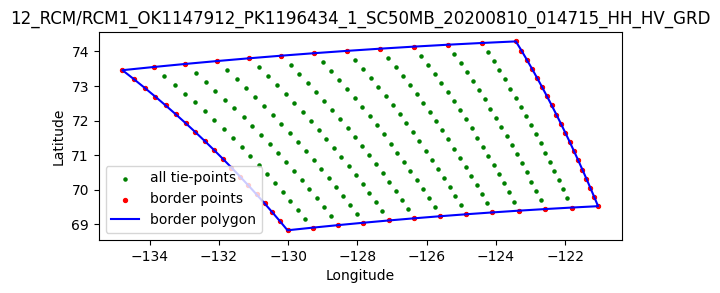

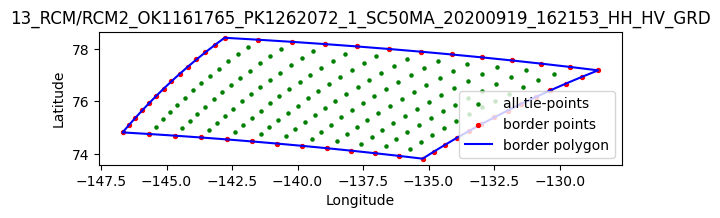


Folder: 12_RCM
{'order_folder': '12_RCM', 'scene_folder': 'RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD', 'footprint': <POLYGON ((-132.413 71.412, -132.148 71.156, -131.889 70.898, -131.637 70.64...>}

Folder: 13_RCM
{'order_folder': '13_RCM', 'scene_folder': 'RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD', 'footprint': <POLYGON ((-145.665 75.93, -145.931 75.651, -146.187 75.372, -146.436 75.093...>}


In [3]:
"""
This code loops through downloaded RCM scenes to extract geolocation tie-points from their product.xml files.  
It identifies tie-points along the image borders and constructs a polygon representing the scene footprint.  
"""

# Calculate RCM polygons using tie-points from product.xml files
rcm_download_root = "./RCM"
rcm_polygons = []

for order_folder in os.listdir(rcm_download_root):
    order_path = os.path.join(rcm_download_root, order_folder)

    for scene_folder in os.listdir(order_path):
        scene_path = os.path.join(order_path, scene_folder)
        product_xml_path = os.path.join(scene_path, scene_folder, "metadata", "product.xml")
        if not os.path.exists(product_xml_path):
            continue                                    

        # parse all tie-points 
        tree = ET.parse(product_xml_path)
        root = tree.getroot()
        ns = {"ns": root.tag.split('}')[0].strip('{')}
        tie_pts = root.findall(".//ns:geolocationGrid/ns:imageTiePoint", namespaces=ns)
        lines, pixels, lats, lons = [], [], [], []
        for tp in tie_pts:
            img = tp.find("ns:imageCoordinate", namespaces=ns)
            geo = tp.find("ns:geodeticCoordinate", namespaces=ns)
            lines.append(float(img.find("ns:line",   namespaces=ns).text))
            pixels.append(float(img.find("ns:pixel", namespaces=ns).text))
            lats.append(float(geo.find("ns:latitude",  namespaces=ns).text))
            lons.append(float(geo.find("ns:longitude", namespaces=ns).text))

        # identify border tie-points 
        min_line, max_line = min(lines), max(lines)
        min_pix,  max_pix  = min(pixels), max(pixels)

        border_mask = [(ln in (min_line, max_line) or
                        px in (min_pix,  max_pix))
                       for ln, px in zip(lines, pixels)]
        border_pts = [(lon, lat) for lon, lat, is_b in
                      zip(lons, lats, border_mask) if is_b]

        if len(border_pts) < 3:                         
            continue

        cx = np.mean([p[0] for p in border_pts])
        cy = np.mean([p[1] for p in border_pts])
        border_pts_sorted = sorted( border_pts, key=lambda p: np.arctan2(p[1] - cy, p[0] - cx))

        footprint = Polygon(border_pts_sorted)
        rcm_polygons.append({
            "order_folder": order_folder,
            "scene_folder": scene_folder,
            "footprint": footprint
        })

        # plot
        plt.figure(figsize=(6, 6))
        plt.scatter(lons,  lats,  s=5,  c="green", label="all tie-points")
        plt.scatter(*zip(*border_pts), s=8, c="red", label="border points")
        x, y = footprint.exterior.xy
        plt.plot(x, y, color="blue", linewidth=1.5, label="border polygon")
        plt.gca().set_aspect("equal", "box")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.title(f"{order_folder}/{scene_folder}")
        plt.legend()
        plt.tight_layout()
        plt.show()

unique_folders = sorted({p["order_folder"] for p in rcm_polygons})
for folder in unique_folders:
    print(f"\nFolder: {folder}")
    for poly in rcm_polygons:
        if poly["order_folder"] == folder:
            print(poly)


Folder: 12  |  Sentinel file: S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc
  Footprint: {'shapefile': '12_S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.zip', 'rcm_folder': '12_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc', 'footprint': <POLYGON ((-120.883 70.182, -121.404 70.245, -121.928 70.307, -122.455 70.36...>}


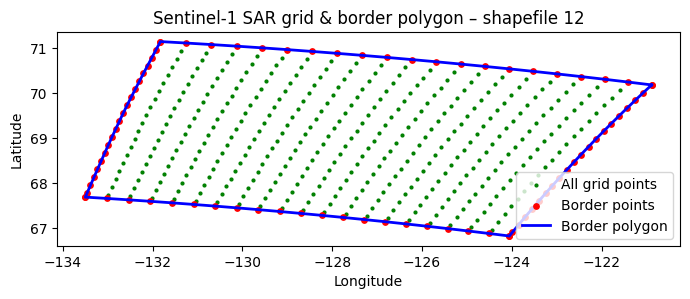


Folder: 13  |  Sentinel file: S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc
  Sentinel: S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc
  Footprint: {'shapefile': '13_S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.zip', 'rcm_folder': '13_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc', 'footprint': <POLYGON ((-126.647 76.851, -127.366 76.941, -128.095 77.028, -128.833 77.11...>}


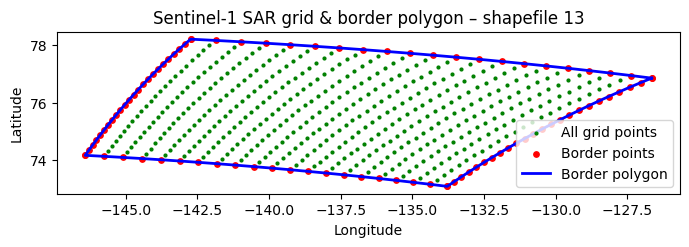

In [4]:
"""
This code matches Sentinel-1 shapefiles to their corresponding NetCDF (.nc) files and extracts valid SAR grid latitude/longitude points.  
It identifies the outer border points of each scene to calculate a polygon representing the Sentinel-1 footprint.  
The resulting footprint is visualized and stored for later comparison with RCM scenes.
"""
sentinel1_data_folder = "./AI4Arctic"
shapefile_folder      = "./AI4Arctic_shapefiles"
rcm_download_root     = "./RCM"

sentinel_footprints = []
available_rcm_folders = {
    f.split("_")[0]
    for f in os.listdir(rcm_download_root)
    if os.path.isdir(os.path.join(rcm_download_root, f)) and f.endswith("_RCM")
}


for shapefile_zip in os.listdir(shapefile_folder):
    match = re.match(r"(\d+)_([^.]+)\.zip", shapefile_zip)
    if not match:
        continue                       
    shapefile_number = match.group(1)  
    shapefile_base   = match.group(2) 
    if shapefile_number not in available_rcm_folders:
        continue

    matched_nc = None
    for nc_file in os.listdir(sentinel1_data_folder):
        if nc_file.endswith(".nc") and shapefile_base in nc_file:
            matched_nc = os.path.join(sentinel1_data_folder, nc_file)
            break
    if matched_nc is None:
        print(f"No matching .nc found for {shapefile_zip}")
        continue

    print(f"\nFolder: {shapefile_number}  |  Sentinel file: {os.path.basename(matched_nc)}")

    ds = xr.open_dataset(matched_nc)
    lat = ds['sar_grid_latitude'].values
    lon = ds['sar_grid_longitude'].values
    line = ds['sar_grid_line'].values      
    sample = ds['sar_grid_sample'].values  

    valid = np.isfinite(lat) & np.isfinite(lon)
    lat, lon, line, sample = lat[valid], lon[valid], line[valid], sample[valid]

    top_mask = line   == line.min()
    bottom_mask = line   == line.max()
    left_mask = sample == sample.min()
    right_mask = sample == sample.max()

    top_idx = np.argsort(sample[top_mask])             # left -> right
    right_idx = np.argsort(line[right_mask])             # top  -> bottom
    bottom_idx = np.argsort(sample[bottom_mask])[::-1]    # right -> left
    left_idx = np.argsort(line[left_mask])[::-1]        # bottom -> top

    border_lats = np.concatenate([
        lat[top_mask][top_idx],
        lat[right_mask][right_idx],
        lat[bottom_mask][bottom_idx],
        lat[left_mask][left_idx]
    ])
    border_lons = np.concatenate([
        lon[top_mask][top_idx],
        lon[right_mask][right_idx],
        lon[bottom_mask][bottom_idx],
        lon[left_mask][left_idx]
    ])

    sentinel_polygon = Polygon(zip(border_lons, border_lats))
    matching_rcm_folder = next(f for f in available_rcm_folders if f == shapefile_number)

    sentinel_footprints.append({
        'shapefile': shapefile_zip,
        'rcm_folder': f"{matching_rcm_folder}_RCM",
        'base_name': os.path.basename(matched_nc),
        'footprint': sentinel_polygon})

    print(f"  Sentinel: {os.path.basename(matched_nc)}")
    print(f"  Footprint: {sentinel_footprints[-1]}") 

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(lon, lat, s=4,  color='green', label='All grid points')
    ax.scatter(border_lons, border_lats, s=15, color='red',   label='Border points')
    poly_x, poly_y = sentinel_polygon.exterior.xy
    ax.plot(poly_x, poly_y, color='blue', linewidth=2, label='Border polygon')
    ax.set_aspect('equal')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(f"Sentinel-1 SAR grid & border polygon – shapefile {shapefile_number}")
    ax.legend(loc='best'); plt.tight_layout(); plt.show()

In [5]:
"""
This code compares each Sentinel-1 footprint with RCM scene polygons to calculate their spatial overlap.  
It selects the RCM scene with the highest intersection area for each Sentinel-1 file and records the overlap percentages.  
"""
best_RCM_match = []

# calculate overlaps between Sentinel-1 and RCM scenes
for sentinel_scene in sentinel_footprints:
    sentinel_footprint = sentinel_scene['footprint']
    sentinel_name = sentinel_scene['shapefile']

    overlaps = []

    for rcm_scene in rcm_polygons:
        if rcm_scene['order_folder'] != sentinel_scene['rcm_folder']:
            continue

        rcm_polygon = rcm_scene['footprint']

        intersection_area = rcm_polygon.intersection(sentinel_footprint).area
        rcm_area = rcm_polygon.area
        sentinel_area = sentinel_footprint.area

        overlaps.append({
            'sentinel_file': sentinel_name,
            'rcm_folder': rcm_scene['order_folder'],
            'rcm_scene': rcm_scene['scene_folder'],
            'overlap_area': intersection_area,
            'overlap_percent_rcm': (intersection_area / rcm_area) * 100,
            'overlap_percent_sentinel': (intersection_area / sentinel_area) * 100
        })

    overlaps_sorted = sorted(overlaps, key=lambda x: x['overlap_area'], reverse=True)
    if overlaps_sorted:
        best_match = overlaps_sorted[:1]
        print(f"\nBest RCM match for Sentinel-1: {sentinel_name}")
        for i, match in enumerate(best_match, 1):
            print(f"\n    RCM Scene: {match['rcm_folder']}/{match['rcm_scene']}")
            print(f"    Overlap Area: {match['overlap_area']:.4f}")
            print(f"    Overlap % of RCM: {match['overlap_percent_rcm']:.2f}%")
            print(f"    Overlap % of Sentinel-1: {match['overlap_percent_sentinel']:.2f}%")
            best_path = os.path.join(rcm_download_root, match['rcm_folder'], match['rcm_scene'],match['rcm_scene'])
            best_RCM_match.append(best_path)

print("\n", best_RCM_match)



Best RCM match for Sentinel-1: 12_S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.zip

    RCM Scene: 12_RCM/RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
    Overlap Area: 14.9757
    Overlap % of RCM: 29.80%
    Overlap % of Sentinel-1: 40.37%

Best RCM match for Sentinel-1: 13_S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.zip

    RCM Scene: 13_RCM/RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD
    Overlap Area: 46.7273
    Overlap % of RCM: 91.72%
    Overlap % of Sentinel-1: 74.13%

 ['./RCM\\12_RCM\\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD', './RCM\\13_RCM\\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD']


In [5]:
# remove other RCM scenes 
best_rcm_scene_dirs = set()
for path in best_RCM_match:
    parts = os.path.normpath(path).split(os.sep)
    rcm_folder = parts[-3]
    rcm_scene = parts[-2]
    full_path = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    best_rcm_scene_dirs.add(full_path)

rcm_root = os.path.join(rcm_download_root)
for folder_name in os.listdir(rcm_root):
    folder_path = os.path.join(rcm_root, folder_name)
    if not os.path.isdir(folder_path):
        continue
    for scene_name in os.listdir(folder_path):
        scene_path = os.path.join(folder_path, scene_name)
        if not os.path.isdir(scene_path):
            continue
        if scene_path not in best_rcm_scene_dirs:
            print(f"Deleting: {scene_path}")
            shutil.rmtree(scene_path)

Calculate the Overlapping and Non-overlapping polygons in Both RCM and Sentinel-1 images


Processing: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD', 'footprint': <POLYGON ((-132.413 71.412, -132.148 71.156, -131.889 70.898, -131.637 70.64...>}]
Matching Sentinel-1 image: 12_S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.zip
Overlap area: POLYGON ((-121.8139445449583 69.48652603554316, -122.5787136046535 69.4432178173118, -123.3402915363951 69.39656602464031, -124.0984646681461 69.34659330269253, -124.8530261831355 69.29332365381487, -125.6037759135825 69.23678240943876, -126.3505205986771 69.17699617314835, -127.0930738749068 69.11399278279947, -127.8312571935436 69.04780118996452, -128.5648993878816 68.97845144540163, -129.2938366417771 68.90597465723513, -130.0179131347195 68.83040287832117, -130.234529092121 69.08974708

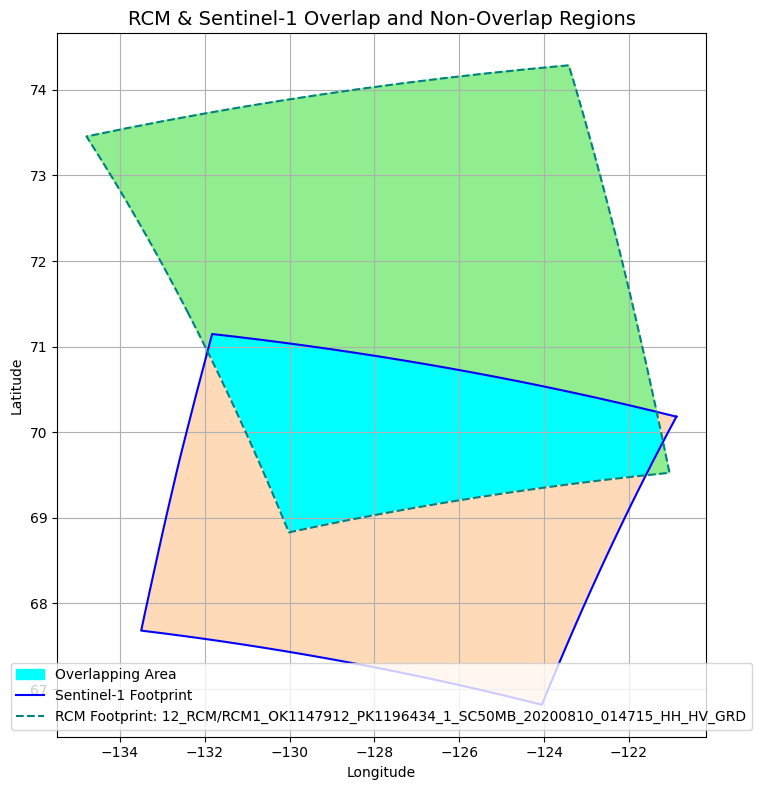

2025-07-04 12:26:27 | pyogrio._io     | INFO     | Created 1 records
2025-07-04 12:26:27 | pyogrio._io     | INFO     | Created 1 records
2025-07-04 12:26:27 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\shapefile_masks

Processing: ./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD
Best Matching RCM Bounding box: [{'folder': 'RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD', 'footprint': <POLYGON ((-145.665 75.93, -145.931 75.651, -146.187 75.372, -146.436 75.093...>}]
Matching Sentinel-1 image: 13_S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.zip
Overlap area: POLYGON ((-129.157799179308 76.92965378562889, -129.7637078707704 76.67570667048494, -130.3482466488928 76.42048270010984, -130.9124998021687 76.16405197577593, -131.4574867687575 75.90647980709024, -131.9841662094735 75.64782708684119, -132.4934397067998 75.388150712723, -132.9861561678057 75.12750350609835, -133.46311386

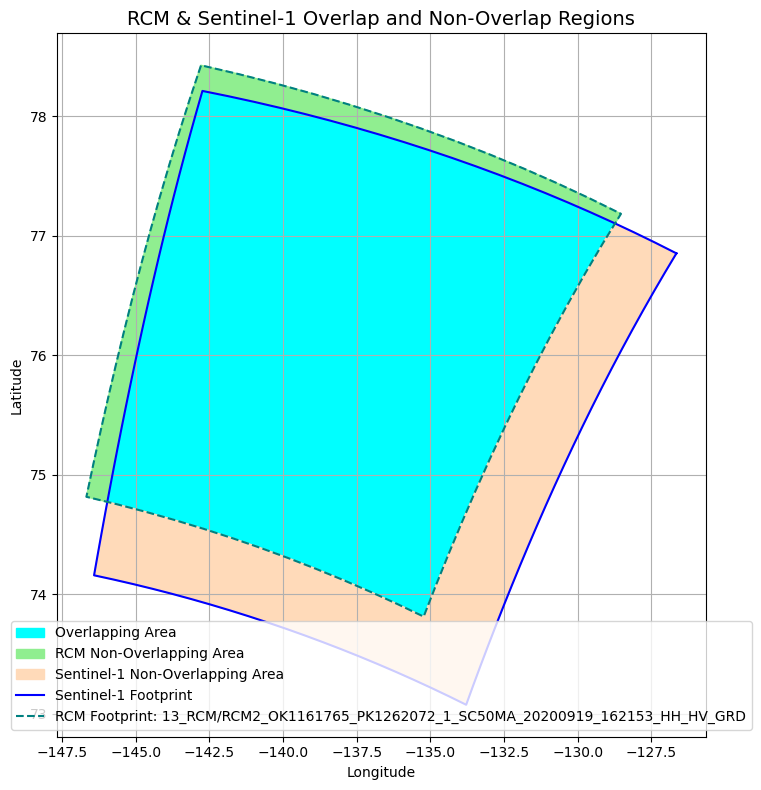

2025-07-04 12:26:27 | pyogrio._io     | INFO     | Created 1 records
2025-07-04 12:26:27 | pyogrio._io     | INFO     | Created 1 records
2025-07-04 12:26:27 | pyogrio._io     | INFO     | Created 1 records


Shapefiles saved to: ./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\shapefile_masks


In [6]:
"""
# For each selected RCM scene, this block rebuilds the scene’s footprint from product.xml tie-points, pairs it with the corresponding Sentinel-1 footprint, and calculates their overlapping and non-overlapping areas.  
# It visualizes the overlapping (cyan), RCM-only (light-green), and Sentinel-only (peach) regions alongside both scene outlines for a clear coverage comparison.  
# The resulting overlap, RCM-exclusive, and Sentinel-exclusive polygons are saved as GeoJSON shapefiles in a “shapefile_masks” directory.
"""
for rcm_path in best_RCM_match:
    print(f"\nProcessing: {rcm_path}")
    parts = rcm_path.split(os.sep)
    rcm_folder = parts[-3]
    rcm_scene = parts[-2]

    best_match = [{'rcm_folder': rcm_folder,'rcm_scene': rcm_scene}]

    rcm_polygons = []
    for match in best_match:
        folder_name = match['rcm_scene']
        order_folder = match['rcm_folder']
        folder_root = os.path.join(rcm_download_root, order_folder, folder_name)
        imagery_path = os.path.join(folder_root, folder_name, 'imagery')
        product_xml_path = os.path.join(folder_root, folder_name, 'metadata', 'product.xml')
        tree = ET.parse(product_xml_path)
        root = tree.getroot()
        ns = {'ns': root.tag.split('}')[0].strip('{')}
        tie_pts = root.findall(".//ns:geolocationGrid/ns:imageTiePoint",namespaces=ns)
        lines, pixels, lats, lons = [], [], [], []
        for tp in tie_pts:
            img = tp.find("ns:imageCoordinate", namespaces=ns)
            geo = tp.find("ns:geodeticCoordinate", namespaces=ns)
            lines.append(float(img.find("ns:line",   namespaces=ns).text))
            pixels.append(float(img.find("ns:pixel", namespaces=ns).text))
            lats.append(float(geo.find("ns:latitude",  namespaces=ns).text))
            lons.append(float(geo.find("ns:longitude", namespaces=ns).text))

        # identify border tie-points 
        min_line, max_line = min(lines), max(lines)
        min_pix,  max_pix  = min(pixels), max(pixels)

        border_mask = [(ln in (min_line, max_line) or
                        px in (min_pix,  max_pix))
                       for ln, px in zip(lines, pixels)]
        border_pts = [(lon, lat) for lon, lat, is_b in
                      zip(lons, lats, border_mask) if is_b]

        if len(border_pts) < 3:                         
            continue

        # order border points clockwise
        cx = np.mean([p[0] for p in border_pts])
        cy = np.mean([p[1] for p in border_pts])
        border_pts_sorted = sorted(
            border_pts,
            key=lambda p: np.arctan2(p[1] - cy, p[0] - cx)
        )

        rcm_footprint = Polygon(border_pts_sorted)
        rcm_polygons.append({'folder': folder_name, 'footprint': rcm_footprint})

    print("Best Matching RCM Bounding box:", rcm_polygons)

    best_rcm_folder = best_match[0]['rcm_folder']
    matched_sentinel = next((s for s in sentinel_footprints if s['rcm_folder'] == best_rcm_folder), None)
    if matched_sentinel is None:
        raise ValueError(f"No matching Sentinel-1 footprint found for {best_rcm_folder}")
    sentinel_footprint = matched_sentinel['footprint']
    print("Matching Sentinel-1 image:", matched_sentinel['shapefile'])

    # calculate the overlapping & non-overlapping areas for both the best RCMs & Sentinel-1
    overlaps = []
    for rcm_poly in rcm_polygons:
        rcm_polygon = rcm_poly['footprint']
        intersection_area = rcm_polygon.intersection(sentinel_footprint).area
        rcm_area = rcm_polygon.area
        sentinel_area = sentinel_footprint.area

    rcm_union = unary_union([item['footprint'] for item in rcm_polygons])
    overlap_area = rcm_union.intersection(sentinel_footprint)
    rcm_non_overlap = rcm_union.difference(sentinel_footprint)
    sentinel_non_overlap = sentinel_footprint.difference(rcm_union)
    print("Overlap area:", overlap_area)
    print("RCM non-overlap area:", rcm_non_overlap)
    print("Sentinel-1 non-overlap area:", sentinel_non_overlap)
    print(rcm_folder)

    # plot
    fig, ax = plt.subplots(figsize=(8, 8))
    if not overlap_area.is_empty:
        if overlap_area.geom_type == 'Polygon':
            ax.fill(*overlap_area.exterior.xy, color='cyan', label='Overlapping Area')
        else:
            for geom in overlap_area.geoms:
                ax.fill(*geom.exterior.xy, color='cyan')

    if not rcm_non_overlap.is_empty:
        if rcm_non_overlap.geom_type == 'Polygon':
            ax.fill(*rcm_non_overlap.exterior.xy, color='lightgreen', label='RCM Non-Overlapping Area')
        else:
            for geom in rcm_non_overlap.geoms:
                ax.fill(*geom.exterior.xy, color='lightgreen')

    if not sentinel_non_overlap.is_empty:
        if sentinel_non_overlap.geom_type == 'Polygon':
            ax.fill(*sentinel_non_overlap.exterior.xy, color='peachpuff', label='Sentinel-1 Non-Overlapping Area')
        else:
            for geom in sentinel_non_overlap.geoms:
                ax.fill(*geom.exterior.xy, color='peachpuff')

    ax.plot(*sentinel_footprint.exterior.xy, color='blue', linewidth=1.5, label='Sentinel-1 Footprint')
    ax.plot(*rcm_union.exterior.xy, color='teal', linestyle='--', linewidth=1.5, label=f"RCM Footprint: {order_folder}/{folder_name}")
    ax.legend(loc='lower center', fontsize=10)
    ax.set_title("RCM & Sentinel-1 Overlap and Non-Overlap Regions", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Save shapefiles
    scene_base = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    shapefile_masks = os.path.join(scene_base,rcm_scene, "shapefile_masks")
    os.makedirs(shapefile_masks, exist_ok=True)
    gpd.GeoDataFrame(geometry=[overlap_area], crs="EPSG:4326").to_file(
        os.path.join(shapefile_masks, "overlap.geojson"), driver="GeoJSON")
    gpd.GeoDataFrame(geometry=[rcm_non_overlap], crs="EPSG:4326").to_file(
        os.path.join(shapefile_masks, "rcm_non_overlap.geojson"), driver="GeoJSON")
    gpd.GeoDataFrame(geometry=[sentinel_non_overlap], crs="EPSG:4326").to_file(
        os.path.join(shapefile_masks, "sentinel_non_overlap.geojson"), driver="GeoJSON")
    print(f"Shapefiles saved to: {shapefile_masks}")

Create RCM & Sentinel-1 Non-overlapping Area Masks

In [7]:
# create the main masks folder and subfolders (rcm_mask_dir,sentinel_mask_dir) in each RCM folder
for rcm_path in best_RCM_match:
    print(f"\nCreating mask folders for: {rcm_path}")
    parts = os.path.normpath(rcm_path).split(os.sep)
    rcm_folder = parts[-3] 
    rcm_scene = parts[-2]  
    scene_base = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    masks_dir = os.path.join(scene_base,rcm_scene, "masks")
    rcm_mask_dir = os.path.join(masks_dir, "rcm_mask")
    sentinel_mask_dir = os.path.join(masks_dir, "sentinel_mask")
    os.makedirs(rcm_mask_dir, exist_ok=True)
    os.makedirs(sentinel_mask_dir, exist_ok=True)
    print(f"Created:\n - {rcm_mask_dir}\n - {sentinel_mask_dir}")


Creating mask folders for: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
Created:
 - ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\masks\rcm_mask
 - ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\masks\sentinel_mask

Creating mask folders for: ./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD
Created:
 - ./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\masks\rcm_mask
 - ./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\masks\sentinel_mask


Create RCM Non-overlapping Area Mask

In [ ]:
"""
This code reads RCM tie-points from product.xml to estimate a geotransform and loads the previously computed non-overlapping region between RCM and Sentinel-1.  
It rasterizes the RCM non-overlapping polygon into a binary mask aligned with the SAR image resolution and visualizes it over geographic coordinates.  
Finally, it saves the generated raster mask as a GeoTIFF.
"""
for rcm_path in best_RCM_match:
    parts = rcm_path.split(os.sep)
    rcm_folder = parts[-3]
    rcm_scene = parts[-2]
    folder_root = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    imagery_path = os.path.join(folder_root,rcm_scene, 'imagery')
    product_xml_path = os.path.join(folder_root,rcm_scene, 'metadata', 'product.xml')
    tree = ET.parse(product_xml_path)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}

    # tie points
    tie_points = []
    for tp in root.findall(".//ns:imageTiePoint", namespaces=ns):
        pixel = float(tp.find(".//ns:imageCoordinate/ns:pixel", namespaces=ns).text)
        line = float(tp.find(".//ns:imageCoordinate/ns:line", namespaces=ns).text)
        lat = float(tp.find(".//ns:geodeticCoordinate/ns:latitude", namespaces=ns).text)
        lon = float(tp.find(".//ns:geodeticCoordinate/ns:longitude", namespaces=ns).text)
        tie_points.append((pixel, line, lon, lat))

    # transform
    pixels = np.array([tp[0] for tp in tie_points])
    lines = np.array([tp[1] for tp in tie_points])
    lons = np.array([tp[2] for tp in tie_points])
    lats = np.array([tp[3] for tp in tie_points])
    pixel_range = pixels.max() - pixels.min()
    line_range = lines.max() - lines.min()
    lon_range = lons.max() - lons.min()
    lat_range = lats.max() - lats.min()
    estimated_xres = lon_range / pixel_range if pixel_range != 0 else 1e-6
    estimated_yres = lat_range / line_range if line_range != 0 else 1e-6
    min_lon = lons.min()
    max_lat = lats.max()
    transform = Affine.translation(min_lon, max_lat) * Affine.scale(estimated_xres, -estimated_yres)
    hh_files = [f for f in os.listdir(imagery_path) if 'HH' in f and f.endswith('.tif')]
    hh_path = os.path.join(imagery_path, hh_files[0])
    with rasterio.open(hh_path) as src:
        image_shape = src.shape
    print(f"\n{rcm_folder}/{rcm_scene}")
    print("  Image shape:", image_shape)

    # load saved RCM overlapping & non-overlapping areas
    scene_base = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
    rcm_non_overlap_path = os.path.join(scene_base, rcm_scene, "shapefile_masks", "rcm_non_overlap.geojson")
    rcm_non_overlap_gdf = gpd.read_file(rcm_non_overlap_path)
    rcm_non_overlap = rcm_non_overlap_gdf.geometry.unary_union
    rcm_union_path = os.path.join(scene_base, rcm_scene, "shapefile_masks", "overlap.geojson")
    rcm_union_gdf = gpd.read_file(rcm_union_path)
    rcm_union = rcm_union_gdf.geometry.unary_union.union(rcm_non_overlap)

    # rasterize non-overlapping mask
    rcm_mask = rasterize(
        [(rcm_non_overlap, 1)],
        out_shape=image_shape,
        transform=transform,
        fill=0,
        dtype='uint8'
    )
    print("Mask shape:", rcm_mask.shape)

    # plot the raster mask with geographic coordinates
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title("RCM Mask vs. Footprint / Non-Overlap")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    minlo, minla, maxlo, maxla = rcm_union.bounds  
    ax.imshow(
        rcm_mask,
        cmap="Greys",                                
        extent=[minlo, maxlo, minla, maxla],        
        origin="upper",
        vmin=0, vmax=1,
        alpha=1.0
    )

    def outline(geom, color, label):
        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.plot(x, y, color=color, lw=2, label=label)
        else:                                        
            for i, g in enumerate(geom.geoms):
                x, y = g.exterior.xy
                ax.plot(x, y, color=color, lw=2,
                        label=label if i == 0 else None)

    outline(rcm_union,       "blue", "RCM Footprint")      
    outline(rcm_non_overlap, "red",  "RCM Non-Overlap")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # save the RCM non-overlapping raster mask
    masks_dir = os.path.join(scene_base, rcm_scene, "masks")
    rcm_mask_dir = os.path.join(masks_dir, "rcm_mask")
    rcm_mask_filename = f"{rcm_scene}_non_overlap_mask.tif"
    rcm_mask_output_path = os.path.join(rcm_mask_dir, rcm_mask_filename)
    with rasterio.open(
        rcm_mask_output_path,
        "w",
        driver="GTiff",
        height=image_shape[0],
        width=image_shape[1],
        count=1,
        dtype=rcm_mask.dtype,
        crs="EPSG:4326",
        transform=transform
    ) as dst:
        dst.write(rcm_mask, 1)


12_RCM/RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
  Image shape: (27077, 18204)


C:\Users\nilofar\AppData\Local\Temp\ipykernel_18832\2641074495.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_non_overlap = rcm_non_overlap_gdf.geometry.unary_union
C:\Users\nilofar\AppData\Local\Temp\ipykernel_18832\2641074495.py:54: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = rcm_union_gdf.geometry.unary_union.union(rcm_non_overlap)


Mask shape: (27077, 18204)

13_RCM/RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD
  Image shape: (20868, 18135)


C:\Users\nilofar\AppData\Local\Temp\ipykernel_18832\2641074495.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_non_overlap = rcm_non_overlap_gdf.geometry.unary_union
C:\Users\nilofar\AppData\Local\Temp\ipykernel_18832\2641074495.py:54: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = rcm_union_gdf.geometry.unary_union.union(rcm_non_overlap)


Mask shape: (20868, 18135)


Create Sentinel-1 Non-overlapping Area Mask

C:\Users\nilofar\AppData\Local\Temp\ipykernel_17052\2247233464.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)
C:\Users\nilofar\AppData\Local\Temp\ipykernel_17052\2247233464.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)


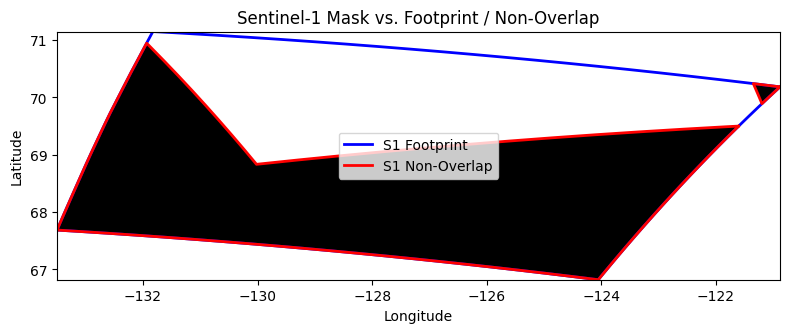

C:\Users\nilofar\AppData\Local\Temp\ipykernel_17052\2247233464.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)
C:\Users\nilofar\AppData\Local\Temp\ipykernel_17052\2247233464.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)


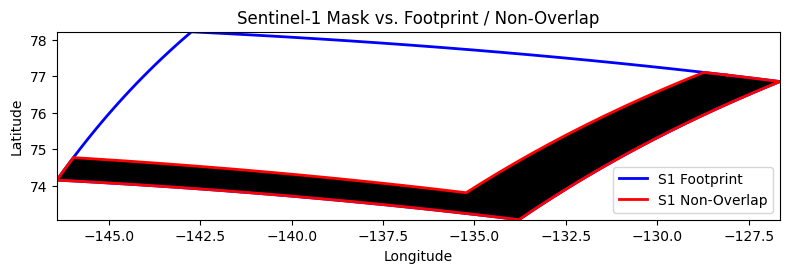

C:\Users\nilofar\AppData\Local\Temp\ipykernel_17052\2247233464.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)
C:\Users\nilofar\AppData\Local\Temp\ipykernel_17052\2247233464.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)


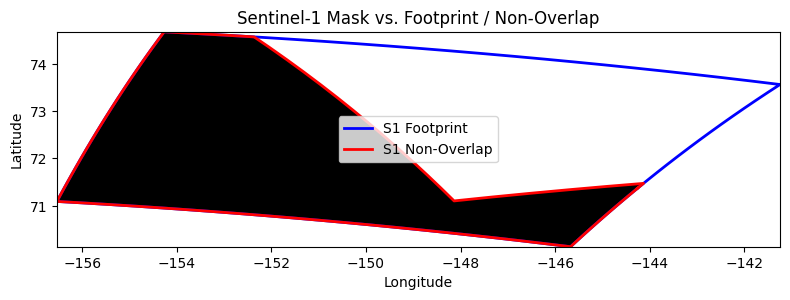

C:\Users\nilofar\AppData\Local\Temp\ipykernel_17052\2247233464.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)
C:\Users\nilofar\AppData\Local\Temp\ipykernel_17052\2247233464.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)


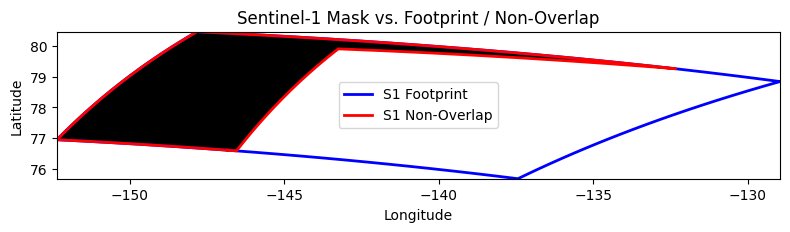

In [ ]:
"""
This code computes the Sentinel-1 area that does not overlap with the RCM footprint.  
It rasterizes this non-overlapping region into a binary mask aligned with the Sentinel-1 image grid and saves it as a GeoTIFF file.  
The mask and footprint are then visualized together to show coverage differences between Sentinel-1 and RCM scenes.
"""
# Build a set of RCM folder names that had the best match
matched_rcm_folders = set()
for rcm_path in best_RCM_match:
    parts = os.path.normpath(rcm_path).split(os.sep)
    rcm_folder = parts[-3]
    matched_rcm_folders.add(rcm_folder)

for sentinel_scene in sentinel_footprints:
    rcm_folder = sentinel_scene['rcm_folder']
    if rcm_folder not in matched_rcm_folders:
        continue 
    sentinel_footprint = sentinel_scene['footprint']
    sentinel_base_name = sentinel_scene['base_name']
    sentinel_nc_path = os.path.join("AI4Arctic", sentinel_base_name)

    ds = xr.open_dataset(sentinel_nc_path)
    image_shape_s1 = ds['nersc_sar_primary'].shape

    # Compute transform from footprint bounds
    minlo, minla, maxlo, maxla = sentinel_footprint.bounds
    xres = (maxlo - minlo) / image_shape_s1[1]
    yres = (maxla - minla) / image_shape_s1[0]
    transform_s1 = Affine.translation(minlo, maxla) * Affine.scale(xres, -yres)

    # Reconstruct RCM scene path and shapefile locations
    rcm_scene_path = next((p for p in best_RCM_match if rcm_folder in p), None)
    if rcm_scene_path is None:
        print(f"  Skipping — no matching RCM path found for {rcm_folder}")
        continue

    parts = os.path.normpath(rcm_scene_path).split(os.sep)
    rcm_folder_name = parts[-3]
    rcm_scene_name = parts[-2]
    scene_base = os.path.join(rcm_download_root, rcm_folder_name, rcm_scene_name)
    overlap_path = os.path.join(scene_base, rcm_scene_name, "shapefile_masks", "overlap.geojson")
    non_overlap_path = os.path.join(scene_base, rcm_scene_name, "shapefile_masks", "rcm_non_overlap.geojson")

    if not os.path.exists(overlap_path) or not os.path.exists(non_overlap_path):
        print(f"  Missing shapefiles for {rcm_scene_name}, skipping.")
        continue

    rcm_union = gpd.read_file(overlap_path).geometry.unary_union.union(gpd.read_file(non_overlap_path).geometry.unary_union)

    # Compute non-overlapping Sentinel-1 area
    sentinel_non_overlap = sentinel_footprint.difference(rcm_union)

    # Rasterize mask
    s1_mask = rasterize(
        [(sentinel_non_overlap, 1)],
        out_shape=image_shape_s1,
        transform=transform_s1,
        fill=0,
        dtype='uint8'
    )

    masks_dir = os.path.join(scene_base, rcm_scene_name, "masks")
    sentinel_mask_dir = os.path.join(masks_dir, "sentinel_mask")
    os.makedirs(sentinel_mask_dir, exist_ok=True)
    sentinel_mask_filename = f"{sentinel_base_name}_non_overlap_mask.tif"
    sentinel_mask_output_path = os.path.join(sentinel_mask_dir, sentinel_mask_filename)

    with rasterio.open(
        sentinel_mask_output_path,
        "w",
        driver="GTiff",
        height=image_shape_s1[0],
        width=image_shape_s1[1],
        count=1,
        dtype=s1_mask.dtype,
        crs="EPSG:4326",
        transform=transform_s1
    ) as dst:
        dst.write(s1_mask, 1)


    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title("Sentinel-1 Mask vs. Footprint / Non-Overlap")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    minlo, minla, maxlo, maxla = sentinel_footprint.bounds
    ax.imshow(
        s1_mask,
        cmap="Greys",                        
        extent=[minlo, maxlo, minla, maxla],  
        origin="upper",                     
        vmin=0,
        vmax=1,
        alpha=1.0                         
    )

    def plot_outline(geom, ax, color, label):
        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.plot(x, y, color=color, linewidth=2, label=label)
        elif geom.geom_type == "MultiPolygon":
            for i, g in enumerate(geom.geoms):
                x, y = g.exterior.xy
                ax.plot(x, y, color=color, linewidth=2, label=label if i == 0 else None)
    plot_outline(sentinel_footprint, ax, color="blue", label="S1 Footprint")
    plot_outline(sentinel_non_overlap, ax, color="red", label="S1 Non-Overlap")
    ax.legend()
    plt.tight_layout()
    plt.show()

Coregistering RCM and Sentinel-1 & Cropping the RCM image based on the S1 shapefile

In [11]:
# Extract RCM sparse geolocation tie points (line, pixel) to geographic (lat, lon) from product.xml
def parse_rcm_tie_points(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}
    lines, pixels, lats, lons = [], [], [], []
    for tp in root.findall(".//ns:geolocationGrid/ns:imageTiePoint", namespaces=ns):
        img = tp.find("ns:imageCoordinate", namespaces=ns)
        geo = tp.find("ns:geodeticCoordinate", namespaces=ns)
        lines.append(float(img.find("ns:line",   namespaces=ns).text))
        pixels.append(float(img.find("ns:pixel", namespaces=ns).text))
        lats.append(float(geo.find("ns:latitude",  namespaces=ns).text))
        lons.append(float(geo.find("ns:longitude", namespaces=ns).text))
    return np.array(lines), np.array(pixels), np.array(lats), np.array(lons)


# Load S1 NetCDF and interpolate lat/lon to every pixel of the full S1 image grid
matched_rcm_set     = {os.path.normpath(p).split(os.sep)[-3] for p in best_RCM_match}
matched_rcm_folders = sorted(matched_rcm_set, key=lambda f: int(f.split('_')[0]))
print(matched_rcm_folders)
for sentinel_scene in sentinel_footprints:
    print(sentinel_scene)
    rcm_folder = sentinel_scene['rcm_folder']
    if rcm_folder not in matched_rcm_folders:
        continue
    sentinel_nc_path = os.path.join("./AI4Arctic", sentinel_scene['base_name'])
    print(f"Using .nc file: {sentinel_nc_path}")
    ds          = Dataset(sentinel_nc_path, "r")
    s1_data     = ds.variables["nersc_sar_primary"][:]
    rows_s1, cols_s1 = s1_data.shape
    lines_s1    = ds.variables["sar_grid_line"][:]
    samples_s1  = ds.variables["sar_grid_sample"][:]
    lats_s1     = ds.variables["sar_grid_latitude"][:]
    lons_s1     = ds.variables["sar_grid_longitude"][:]
    ds.close()
    s1_grid_row, s1_grid_col = np.meshgrid(np.arange(rows_s1), np.arange(cols_s1), indexing='ij')
    points_s1 = np.column_stack((lines_s1, samples_s1))
    s1_pixel_coords = np.column_stack((s1_grid_row.ravel(), s1_grid_col.ravel()))
    lat_s1_grid = griddata(points_s1, lats_s1, s1_pixel_coords, method='cubic').reshape(rows_s1, cols_s1)
    lon_s1_grid = griddata(points_s1, lons_s1, s1_pixel_coords, method='cubic').reshape(rows_s1, cols_s1)

    # Interpolate S1 lat/lon to RCM pixel locations
    # Resample RCM image onto Sentinel-1 pixel grid and attach GCPs
    order_path = os.path.join("./RCM", rcm_folder)
    for scene_folder in os.listdir(order_path):
        scene_path = os.path.join(order_path, scene_folder, scene_folder)

        
        '''
        interpolation functions that map geographic coordinates (lat, lon) back to RCM image pixel coordinates.  
        This inverse mapping lets us find, for each pixel in the S1 grid (with known lat/lon), the corresponding location in the RCM image.  
        '''
        rcm_xml_path = os.path.join(scene_path, "metadata", "product.xml")
        print(rcm_xml_path)
        lines_rcm, pixels_rcm, lats_rcm, lons_rcm = parse_rcm_tie_points(rcm_xml_path)
        print(f"  pairing S1 = {sentinel_nc_path}  ↔  RCM = {order_path}")
        points_rcm_geo = np.column_stack((lats_rcm, lons_rcm))
        latlon_coords  = np.column_stack((lat_s1_grid.ravel(), lon_s1_grid.ravel()))
        rcm_row_map    = griddata(points_rcm_geo, lines_rcm,   latlon_coords,  method='cubic').reshape(rows_s1, cols_s1)
        rcm_col_map    = griddata(points_rcm_geo, pixels_rcm,  latlon_coords,  method='cubic').reshape(rows_s1, cols_s1)
        

        '''
        With the coordinate maps (`rcm_row_map`, `rcm_col_map`), we use `map_coordinates` to resample the original RCM image to the S1 pixel grid.  
        We then prepare Ground Control Points (GCPs) from the Sentinel-1 sparse grid, which contain georeferencing info (pixel to lat/lon).  
        Finally, we save the resampled RCM image **directly with the GCPs attached** to enable georeferencing without intermediate files.
        '''
        imagery_path = os.path.join(scene_path, "imagery")
        if not os.path.isdir(imagery_path):
            continue

        for tif_name in os.listdir(imagery_path):
            if not tif_name.lower().endswith(".tif"):
                continue
            rcm_raster_path = os.path.join(imagery_path, tif_name)
            with rasterio.open(rcm_raster_path) as rcm_src:
                rcm_data    = rcm_src.read(1)
                rcm_profile = rcm_src.profile

            # Resample RCM data to Sentinel-1 grid coordinates (assumes rcm_row_map, rcm_col_map, rows_s1, cols_s1 are ready)
            coords    = np.vstack([rcm_row_map.ravel(), rcm_col_map.ravel()])
            resampled = map_coordinates(rcm_data, coords, order=1, mode='nearest').reshape(rows_s1, cols_s1)

            # Prepare GCPs from Sentinel-1 sparse grid
            gcps = []
            for line, sample, lat, lon in zip(
                lines_s1, samples_s1, lats_s1, lons_s1
            ):
                row = int(round(line))
                col = int(round(sample))
                if 0 <= row < rows_s1 and 0 <= col < cols_s1:
                    gcps.append(
                        GroundControlPoint(row=row, col=col, x=lon, y=lat)
                    )

            # Update profile for new resampled image
            profile = rcm_profile.copy()
            profile.update({
                "height": rows_s1,
                "width":  cols_s1,
                "dtype":  resampled.dtype,
                "count":  1,
            })
            profile.pop('nodata', None)

            out_path = os.path.join(
                imagery_path,
                f"{os.path.splitext(tif_name)[0]}_resampled_to_s1_grid_gcps.tif"
            )
            print(f"{out_path}  →  shape: {resampled.shape}")

            # Write resampled RCM image directly with GCPs
            with rasterio.open(out_path, "w", **profile) as dst:
                dst.write(resampled, 1)
                dst.gcps = (gcps, CRS.from_epsg(4326))

            print(f"Resampled RCM image saved with GCPs: {out_path}")


['12_RCM', '13_RCM']
{'shapefile': '12_S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.zip', 'rcm_folder': '12_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc', 'footprint': <POLYGON ((-120.883 70.182, -121.404 70.245, -121.928 70.307, -122.455 70.36...>}
Using .nc file: ./AI4Arctic\S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc
./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\metadata\product.xml
  pairing S1 = ./AI4Arctic\S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc  ↔  RCM = ./RCM\12_RCM
./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\imagery\11

c:\Users\nilofar\AppData\Local\Programs\Python\Python311\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
2025-07-04 12:46:11 | rasterio._env   | WARNING  | CPLE_AppDefined in 1196434_1_HH_resampled_to_s1_grid_gcps.tif: A geotransform previously set is going to be cleared due to the setting of GCPs.


Resampled RCM image saved with GCPs: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\imagery\1196434_1_HH_resampled_to_s1_grid_gcps.tif
./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\imagery\1196434_1_HV_resampled_to_s1_grid_gcps.tif  →  shape: (9733, 10451)


2025-07-04 12:46:25 | rasterio._env   | WARNING  | CPLE_AppDefined in 1196434_1_HV_resampled_to_s1_grid_gcps.tif: A geotransform previously set is going to be cleared due to the setting of GCPs.


Resampled RCM image saved with GCPs: ./RCM\12_RCM\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD\imagery\1196434_1_HV_resampled_to_s1_grid_gcps.tif
{'shapefile': '13_S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.zip', 'rcm_folder': '13_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc', 'footprint': <POLYGON ((-126.647 76.851, -127.366 76.941, -128.095 77.028, -128.833 77.11...>}
Using .nc file: ./AI4Arctic\S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc
./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\metadata\product.xml
  pairing S1 = ./AI4Arctic\S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_c

2025-07-04 12:47:40 | rasterio._env   | WARNING  | CPLE_AppDefined in 1262072_1_HH_resampled_to_s1_grid_gcps.tif: A geotransform previously set is going to be cleared due to the setting of GCPs.


Resampled RCM image saved with GCPs: ./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\imagery\1262072_1_HH_resampled_to_s1_grid_gcps.tif
./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\imagery\1262072_1_HV_resampled_to_s1_grid_gcps.tif  →  shape: (11497, 10375)


2025-07-04 12:47:49 | rasterio._env   | WARNING  | CPLE_AppDefined in 1262072_1_HV_resampled_to_s1_grid_gcps.tif: A geotransform previously set is going to be cleared due to the setting of GCPs.


Resampled RCM image saved with GCPs: ./RCM\13_RCM\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD\imagery\1262072_1_HV_resampled_to_s1_grid_gcps.tif


c:\Users\nilofar\AppData\Local\Programs\Python\Python311\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Saved Sentinel-1 raw image with GCPs: nersc_sar_primary_gcps.tif


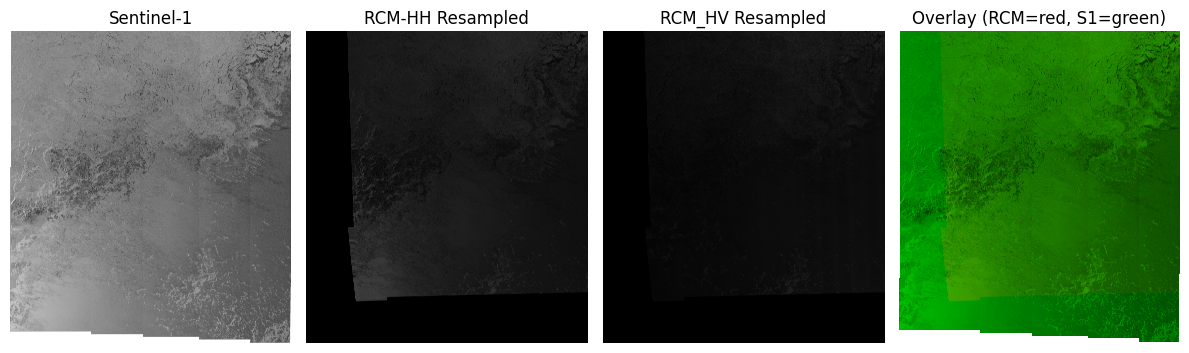

In [ ]:
# test
'''
To enable direct georeferencing, we save the original Sentinel-1 SAR data as a GeoTIFF with the same GCPs attached.  
This makes it easier to visualize and compare the S1 and resampled RCM images in GIS tools.
'''
initial_s1_tif = "nersc_sar_primary_gcps.tif"
with rasterio.open(
    initial_s1_tif,
    "w",
    driver="GTiff",
    height=rows_s1,
    width=cols_s1,
    count=1,
    dtype=s1_data.dtype,
    crs=CRS.from_epsg(4326),
    nodata=np.nan
) as dst:
    dst.write(s1_data, 1)
    dst.gcps = (gcps, CRS.from_epsg(4326))
print(f"Saved Sentinel-1 raw image with GCPs: {initial_s1_tif}")


# Visualization
def norm(arr):
    arr_min, arr_max = np.nanmin(arr), np.nanmax(arr)
    return (arr - arr_min) / (arr_max - arr_min)

with rasterio.open("nersc_sar_primary_gcps.tif") as s1_src, \
     rasterio.open("./RCM/13_RCM/RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD/RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD/imagery/1262072_1_HH_resampled_to_s1_grid_gcps.tif") as rcm_HH_src, \
     rasterio.open("./RCM/13_RCM/RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD/RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD/imagery/1262072_1_HV_resampled_to_s1_grid_gcps.tif") as rcm_HV_src:
    s1 = s1_src.read(1)
    rcm_HH = rcm_HH_src.read(1)
    rcm_HV = rcm_HV_src.read(1)

s1 = norm(s1)
rcm_HH = norm(rcm_HH)
rcm_HV = norm(rcm_HV)

plt.figure(figsize=(12, 5))
plt.subplot(1, 4, 1)
plt.imshow(s1, cmap="gray")
plt.title("Sentinel-1")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(rcm_HH, cmap="gray")
plt.title("RCM-HH Resampled")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(rcm_HV, cmap="gray")
plt.title("RCM_HV Resampled")
plt.axis("off")
plt.subplot(1, 4, 4)
overlay = np.zeros(s1.shape + (3,))
overlay[..., 0] = rcm_HH  # Red channel
overlay[..., 1] = s1   # Green channel
plt.imshow(overlay)
plt.title("Overlay (RCM=red, S1=green)")
plt.axis("off")
plt.tight_layout()
plt.show()
plt.close()

Calibration into Sigma nought


['1196434_1_HH_resampled_to_s1_grid_gcps.tif']
['1196434_1_HV_resampled_to_s1_grid_gcps.tif']
[INPUT]  1196434_1_HH_resampled_to_s1_grid_gcps.tif  DN shape: (9733, 10451)
[OUTPUT] 1196434_1_HH_resampled_to_s1_grid_gcps.tif  σ⁰ shape: (9733, 10451)
[INPUT]  1196434_1_HV_resampled_to_s1_grid_gcps.tif  DN shape: (9733, 10451)
[OUTPUT] 1196434_1_HV_resampled_to_s1_grid_gcps.tif  σ⁰ shape: (9733, 10451)

[HH] RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 7.99 dB
 - Mean: -67.25 dB
 - DataType: float64

[HV] RCM1_OK1147912_PK1196434_1_SC50MB_20200810_014715_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 0.72 dB
 - Mean: -70.98 dB
 - DataType: float64


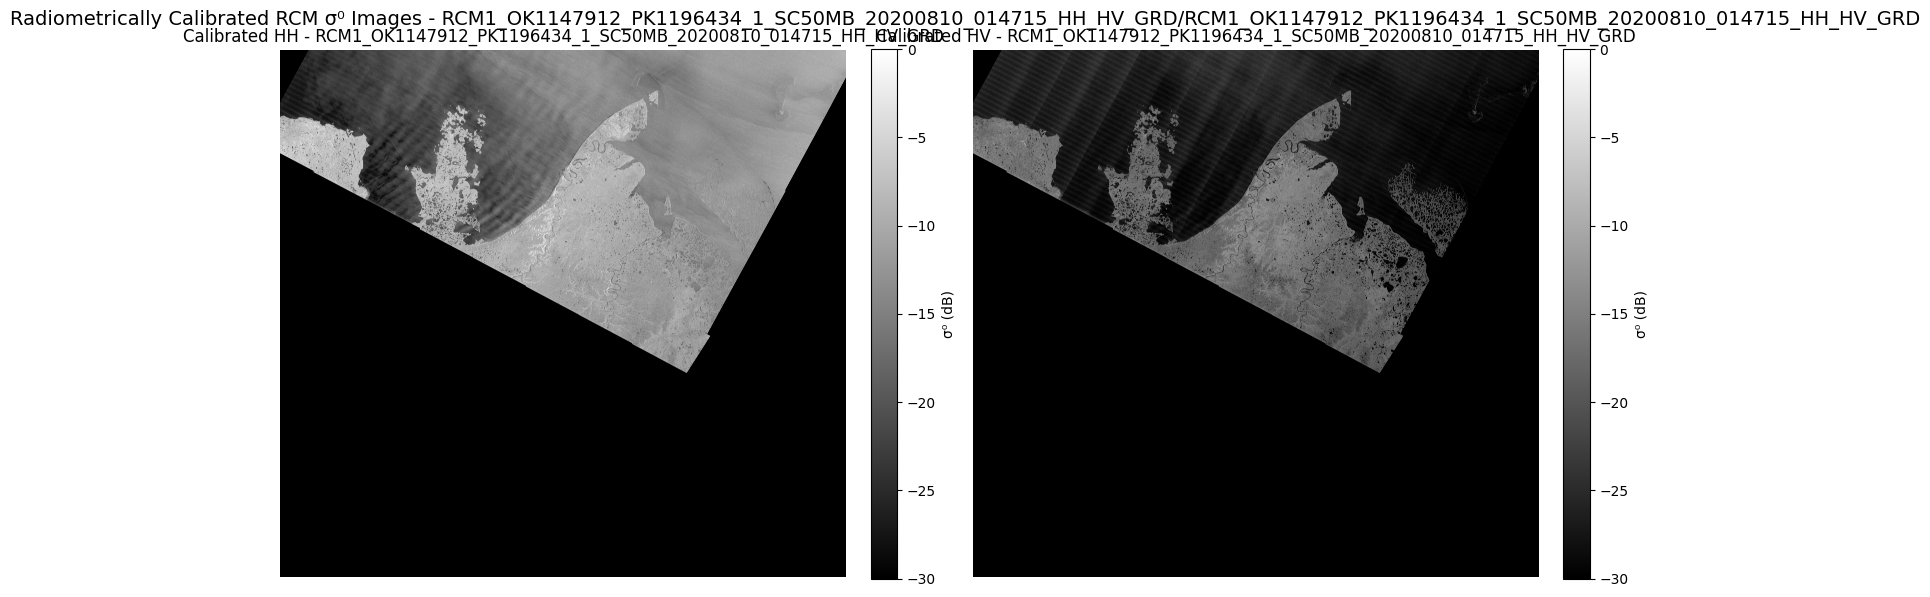

['1262072_1_HH_resampled_to_s1_grid_gcps.tif']
['1262072_1_HV_resampled_to_s1_grid_gcps.tif']
[INPUT]  1262072_1_HH_resampled_to_s1_grid_gcps.tif  DN shape: (11497, 10375)
[OUTPUT] 1262072_1_HH_resampled_to_s1_grid_gcps.tif  σ⁰ shape: (11497, 10375)
[INPUT]  1262072_1_HV_resampled_to_s1_grid_gcps.tif  DN shape: (11497, 10375)
[OUTPUT] 1262072_1_HV_resampled_to_s1_grid_gcps.tif  σ⁰ shape: (11497, 10375)

[HH] RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 10.52 dB
 - Mean: -37.22 dB
 - DataType: float64

[HV] RCM2_OK1161765_PK1262072_1_SC50MA_20200919_162153_HH_HV_GRD
 - Min: -100.00 dB
 - Max: 3.44 dB
 - Mean: -46.33 dB
 - DataType: float64


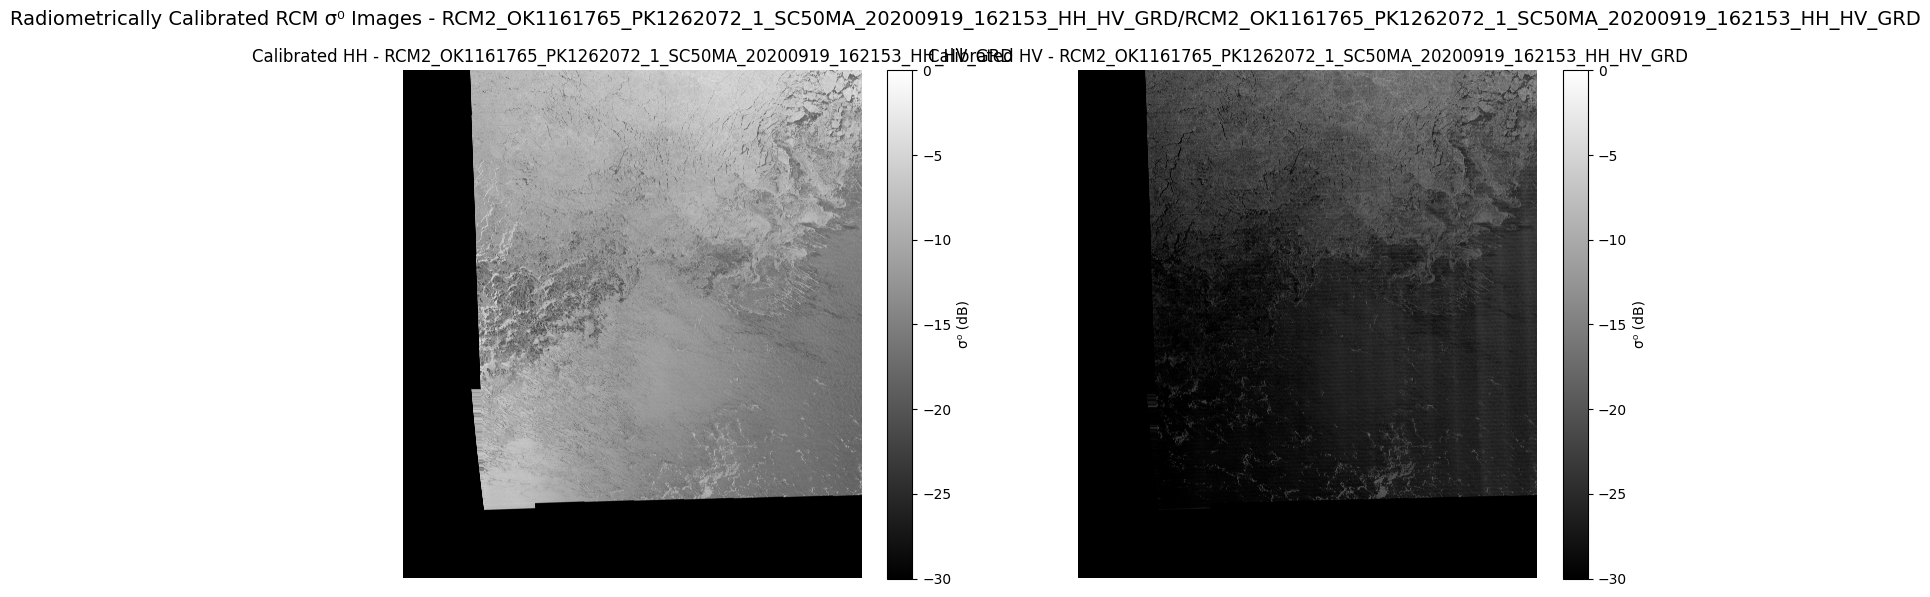

In [13]:
"""
This code performs radiometric calibration of RCM HH and HV TIFF images into Sigma⁰ (σ⁰) backscatter in decibels using look-up tables (LUTs) from XML metadata.  
It reads the digital number (DN) values, applies calibration gains through interpolation, converts to dB scale, and prints summary statistics for each polarization.  
"""
def calibrate_sigma0(tiff_path, lut_path):
    with rasterio.open(tiff_path) as src:
        dn = src.read(1).astype(np.float32)
        print(f"[INPUT]  {os.path.basename(tiff_path)}  DN shape: {dn.shape}") 
        tags = src.tags()
        profile = src.profile
        if src.nodata is not None:
            dn = np.ma.masked_equal(dn, src.nodata)
    tree = ET.parse(lut_path)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}
    gains_elem = root.find("ns:gains", ns)
    gains_text = gains_elem.text.strip()
    gains = np.array(list(map(float, gains_text.split())))
    step_size_elem = root.find("ns:stepSize", ns)
    step_size = int(step_size_elem.text.strip())
    height, width = dn.shape
    num_values = len(gains)
    
    if step_size < 0:
        start_row = int(root.find("ns:pixelFirstLutValue", ns).text.strip())
        lut_rows = np.arange(start_row, start_row + step_size * num_values, step_size)
        gains = gains[::-1]
    else:
        lut_rows = np.arange(0, height, step_size)
    lut_rows = lut_rows[:len(gains)]
    interp_func = interp1d(lut_rows, gains[:len(lut_rows)], kind='linear', fill_value='extrapolate')
    gains_full = interp_func(np.arange(height))
    lut_2d = np.tile(gains_full[:, np.newaxis], (1, width))
    sigma0_linear = (dn ** 2) / lut_2d
    sigma0_dB = 10 * np.log10(sigma0_linear + 1e-10)
    print(f"[OUTPUT] {os.path.basename(tiff_path)}  σ⁰ shape: {sigma0_dB.shape}")
    return sigma0_dB, profile, tags
 
 
for folder_path in best_RCM_match:
    folder_name = os.path.basename(folder_path)        
    order_folder = os.path.basename(os.path.dirname(folder_path))
    folder_root = folder_path
    imagery_path = os.path.join(folder_root, 'imagery')
    calibration_path = os.path.join(folder_root, 'metadata', 'calibration')
    hh_files = [f for f in os.listdir(imagery_path) if 'HH' in f and f.endswith('_resampled_to_s1_grid_gcps.tif')]
    print(hh_files)
    hv_files = [f for f in os.listdir(imagery_path) if 'HV' in f and f.endswith('_resampled_to_s1_grid_gcps.tif')]
    print(hv_files)
    hh_path = os.path.join(imagery_path, hh_files[0])
    hv_path = os.path.join(imagery_path, hv_files[0])
    lut_hh_path = os.path.join(calibration_path, "lutSigma_HH.xml")
    lut_hv_path = os.path.join(calibration_path, "lutSigma_HV.xml")
 
 
    # Calibrate HH, HV
    sigma0_dB_HH, profile_HH, tags_HH = calibrate_sigma0(hh_path, lut_hh_path)
    sigma0_dB_HV, profile_HV, tags_HV = calibrate_sigma0(hv_path, lut_hv_path)
 

    print(f"\n[HH] {folder_name}")
    print(f" - Min: {sigma0_dB_HH.min():.2f} dB")
    print(f" - Max: {sigma0_dB_HH.max():.2f} dB")
    print(f" - Mean: {sigma0_dB_HH.mean():.2f} dB")
    print(f" - DataType: {sigma0_dB_HH.dtype}")
    print(f"\n[HV] {folder_name}")
    print(f" - Min: {sigma0_dB_HV.min():.2f} dB")
    print(f" - Max: {sigma0_dB_HV.max():.2f} dB")
    print(f" - Mean: {sigma0_dB_HV.mean():.2f} dB")
    print(f" - DataType: {sigma0_dB_HV.dtype}")


    calibrated_dir = os.path.join(folder_root, 'calibrated_imagery')
    os.makedirs(calibrated_dir, exist_ok=True)
    # Save HH
    profile_HH.update(dtype='float32', count=1, compress='lzw')
    save_path_HH = os.path.join(calibrated_dir, f"{folder_name}_sigma0_HH_dB.tif")
    with rasterio.open(save_path_HH, 'w', **profile_HH) as dst:
        dst.write(sigma0_dB_HH.astype(np.float32), 1)
        dst.update_tags(**tags_HH)
    # Save HV
    profile_HV.update(dtype='float32', count=1, compress='lzw')
    save_path_HV = os.path.join(calibrated_dir, f"{folder_name}_sigma0_HV_dB.tif")
    with rasterio.open(save_path_HV, 'w', **profile_HV) as dst:
        dst.write(sigma0_dB_HV.astype(np.float32), 1)
        dst.update_tags(**tags_HV)


    # Plot calibrated images
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    im1 = axs[0].imshow(sigma0_dB_HH, cmap='gray', vmin=-30, vmax=0)
    axs[0].set_title(f"Calibrated HH - {order_folder}")
    axs[0].axis('off')
    fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04, label='σ⁰ (dB)')

    im2 = axs[1].imshow(sigma0_dB_HV, cmap='gray', vmin=-30, vmax=0)
    axs[1].set_title(f"Calibrated HV - {order_folder}")
    axs[1].axis('off')
    fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04, label='σ⁰ (dB)')

    plt.suptitle(f"Radiometrically Calibrated RCM σ⁰ Images - {order_folder}/{folder_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


    # # Plot histograms
    # fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    # axs[0].hist(sigma0_dB_HH.flatten(), bins=256, color='gray', edgecolor='black')
    # axs[0].set_title(f"Histogram HH - {folder_name}")
    # axs[0].set_xlabel("Backscatter (dB)")
    # axs[0].set_ylabel("Frequency")
    # axs[0].grid(True, linestyle='--', alpha=0.6)
 
    # axs[1].hist(sigma0_dB_HV.flatten(), bins=256, color='gray', edgecolor='black')
    # axs[1].set_title(f"Histogram HV - {folder_name}")
    # axs[1].set_xlabel("Backscatter (dB)")
    # axs[1].set_ylabel("Frequency")
    # axs[1].grid(True, linestyle='--', alpha=0.6)
 
    # plt.suptitle(f"Calibrated σ⁰ Histograms for {folder_name}")
    # plt.tight_layout()
    # plt.show()


Update the .nc files with new variables (RCM SAR images + Masks + geo info)

In [10]:
"""
This code loads raw and calibrated RCM SAR data, non-overlap masks, and metadata for each matched Sentinel-1 scene and appends them to the corresponding Sentinel-1 NetCDF file.  
It extracts and stores RCM tie-point geolocation (lat/lon), pixel coordinates, and incidence angle data from XML metadata.  
"""
def load_geotiff(filepath):
    with rasterio.open(filepath) as src:
        return src.read(1)
 
matched_rcm_folders = set()
for rcm_path in best_RCM_match:
    parts = os.path.normpath(rcm_path).split(os.sep)
    rcm_folder = parts[-2] 
    matched_rcm_folders.add(rcm_folder)

matched_pairs = []

for sentinel_scene in sentinel_footprints:
    rcm_folder = sentinel_scene['rcm_folder']
    base_name = sentinel_scene['base_name']
    nc_path = os.path.join("./AI4Arctic", base_name)
    matched_pairs.append((sentinel_scene, nc_path))

print(matched_pairs)
output_dir = "new_AI4Arctic"
os.makedirs(output_dir, exist_ok=True)
 
for sentinel_scene, nc_path in matched_pairs:
    rcm_folder = sentinel_scene['rcm_folder']
    base_name = sentinel_scene['base_name']
    print(rcm_folder,base_name )
 
    rcm_scene_path = next((p for p in best_RCM_match if rcm_folder in p), None)
    parts = os.path.normpath(rcm_scene_path).split(os.sep)
    rcm_scene = parts[-1]
    full_rcm_path = os.path.join(rcm_download_root, rcm_folder, rcm_scene)
 
    cal_imagery_folder = os.path.join(full_rcm_path,rcm_scene, 'calibrated_imagery')
    sar_RCM_HH_cal = next((os.path.join(cal_imagery_folder, f) for f in os.listdir(cal_imagery_folder) if f.endswith("_HH_dB.tif")), None)
    sar_RCM_HV_cal = next((os.path.join(cal_imagery_folder, f) for f in os.listdir(cal_imagery_folder) if f.endswith("_HV_dB.tif")), None)
    print(sar_RCM_HH_cal)
    imagery_folder = os.path.join(full_rcm_path,rcm_scene, 'imagery')
    orig_sar_RCM_HH = next((os.path.join(imagery_folder, f) for f in os.listdir(imagery_folder) if f.endswith("_HH.tif")), None)
    orig_sar_RCM_HV = next((os.path.join(imagery_folder, f) for f in os.listdir(imagery_folder) if f.endswith("_HV.tif")), None)
 
    mask_RCM = os.path.join(full_rcm_path, rcm_scene, 'masks', 'rcm_mask', f"{rcm_scene}_non_overlap_mask.tif")
    mask_sentinel = os.path.join(full_rcm_path,rcm_scene, 'masks', 'sentinel_mask', f"{base_name}_non_overlap_mask.tif")
 
    sar_RCM_HH_cal = np.flipud(load_geotiff(sar_RCM_HH_cal))
    print(sar_RCM_HH_cal.shape)
    sar_RCM_HV_cal = np.flipud(load_geotiff(sar_RCM_HV_cal))
    orig_sar_RCM_HH = np.flipud(load_geotiff(orig_sar_RCM_HH))
    orig_sar_RCM_HV = np.flipud(load_geotiff(orig_sar_RCM_HV))
    mask_RCM = np.flipud(load_geotiff(mask_RCM))
    mask_sentinel = np.flipud(load_geotiff(mask_sentinel))
    print(mask_sentinel.shape)
 
    ds = xr.open_dataset(nc_path)
    ds["orig_sar_RCM_HH"] = xr.DataArray(orig_sar_RCM_HH, dims=["sar_lines_rcm", "sar_samples_rcm"])
    ds["orig_sar_RCM_HV"] = xr.DataArray(orig_sar_RCM_HV, dims=["sar_lines_rcm", "sar_samples_rcm"])
    ds["sar_RCM_HH_cal"] = xr.DataArray(sar_RCM_HH_cal, dims=["sar_lines", "sar_samples"])
    ds["sar_RCM_HV_cal"] = xr.DataArray(sar_RCM_HV_cal, dims=["sar_lines", "sar_samples"])
    ds["mask_RCM"] = xr.DataArray(mask_RCM, dims=["sar_lines_rcm", "sar_samples_rcm"])
    ds["mask_sentinel"] = xr.DataArray(mask_sentinel, dims=["sar_lines", "sar_samples"])
 
    product_xml = os.path.join(full_rcm_path, rcm_scene, 'metadata', 'product.xml')
    tree = ET.parse(product_xml)
    root = tree.getroot()
    ns = {'ns': root.tag.split('}')[0].strip('{')}
    tie_points = root.findall(".//ns:geolocationGrid/ns:imageTiePoint", namespaces=ns)
    lines, pixels, lats, lons = [], [], [], []
    for pt in tie_points:
        lines.append(float(pt.find(".//ns:imageCoordinate/ns:line", ns).text))
        pixels.append(float(pt.find(".//ns:imageCoordinate/ns:pixel", ns).text))
        lats.append(float(pt.find(".//ns:geodeticCoordinate/ns:latitude", ns).text))
        lons.append(float(pt.find(".//ns:geodeticCoordinate/ns:longitude", ns).text))

    angle_path = os.path.join(full_rcm_path, rcm_scene, 'metadata', 'calibration', 'incidenceAngles.xml')
    angle_tree = ET.parse(angle_path)
    angle_root = angle_tree.getroot()
    angle_ns = {'ns': angle_root.tag.split('}')[0].strip('{')}
    angles = np.array([float(a.text) for a in angle_root.findall(".//ns:angles", angle_ns)])    
    pixel_first = int(angle_root.find(".//ns:pixelFirstAnglesValue", angle_ns).text)
    step_size   = int(angle_root.find(".//ns:stepSize", angle_ns).text)
    pixel_idx   = pixel_first + np.arange(angles.size) * step_size
 
    dim_name = "sar_grid_points_rcm"
    ds["sar_grid_line_rcm"] = xr.DataArray(np.array(lines), dims=[dim_name])
    ds["sar_grid_sample_rcm"] = xr.DataArray(np.array(pixels), dims=[dim_name])
    ds["sar_grid_latitude_rcm"] = xr.DataArray(np.array(lats), dims=[dim_name])
    ds["sar_grid_longitude_rcm"] = xr.DataArray(np.array(lons), dims=[dim_name])

    dim_ang = "sar_pixel_rcm"     
    ds = ds.assign_coords({dim_ang: pixel_idx})
    ds["sar_grid_incidenceangle_rcm"] = xr.DataArray(angles, dims=[dim_ang])
    out_path = os.path.join(output_dir, f"{base_name}")
    ds.to_netcdf(out_path)

[({'shapefile': '12_S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.zip', 'rcm_folder': '12_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc', 'footprint': <POLYGON ((-120.883 70.182, -121.404 70.245, -121.928 70.307, -122.455 70.36...>}, './AI4Arctic\\S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc'), ({'shapefile': '13_S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.zip', 'rcm_folder': '13_RCM', 'base_name': 'S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_20200919T1624Z_pl_a.nc', 'footprint': <POLYGON ((-126.647 76.851, -127.366 76.941, -128.095 77.028, -128.833 77.11...>}, './AI4Arctic\\S1A_EW_GRDM_1SDH_20200919T161650_20200919T161759_034430_04014D_1137_icechart_cis_SGRDIWA_202

In [30]:
# test new AI4Arctic
test_path = "./new_AI4Arctic/S1A_EW_GRDM_1SDH_20200810T151258_20200810T151357_033846_03ECB0_0878_icechart_cis_SGRDIWA_20200810T1522Z_pl_a.nc"
ds = xr.open_dataset(test_path)
print(ds.dims)
for var_name in ds.variables:
    print(f" - {var_name} → {ds[var_name].dims} | shape: {ds[var_name].shape}")


FrozenMappingWarningOnValuesAccess({'sar_lines': 9733, 'sar_samples': 10451, 'sar_grid_points': 441, 'polygon_codes': 7, '2km_grid_lines': 194, '2km_grid_samples': 209, 'sar_lines_rcm': 27077, 'sar_samples_rcm': 18204, 'sar_grid_points_rcm': 247, 'sar_pixel_rcm': 793})
 - nersc_sar_primary → ('sar_lines', 'sar_samples') | shape: (9733, 10451)
 - nersc_sar_secondary → ('sar_lines', 'sar_samples') | shape: (9733, 10451)
 - polygon_icechart → ('sar_lines', 'sar_samples') | shape: (9733, 10451)
 - distance_map → ('sar_lines', 'sar_samples') | shape: (9733, 10451)
 - sar_grid_line → ('sar_grid_points',) | shape: (441,)
 - sar_grid_sample → ('sar_grid_points',) | shape: (441,)
 - sar_grid_latitude → ('sar_grid_points',) | shape: (441,)
 - sar_grid_longitude → ('sar_grid_points',) | shape: (441,)
 - sar_grid_incidenceangle → ('sar_grid_points',) | shape: (441,)
 - sar_grid_height → ('sar_grid_points',) | shape: (441,)
 - polygon_codes → ('polygon_codes',) | shape: (7,)
 - btemp_6_9h → ('2km_g